# QVM ENGINE V3 F-SCORE INTEGRATION TEARSHEET

This notebook demonstrates the QVM (Quality, Value, Momentum) factor investing strategy with Piotroski F-Score integration and comprehensive performance analysis.

**Key Changes:** 
- Piotroski F-Score integration into Quality factor (15% weight)
- Enhanced quality factor weighting: Level (40%), Change (25%), Acceleration (20%), F-Score (15%)
- Sector-specific F-Score calculations: Non-Financial (9 tests), Banking (6 tests), Securities (5 tests)
- Real-time F-Score calculation from database
- Cash allocation tracking below equity curve
- Fixed portfolio size: exactly 20 stocks per rebalancing date

# IMPORTS AND SETUP

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [63]:
import sys
sys.path.append('/home/raymond/Documents/Projects/factor-investing-public')
from production.database.connection import DatabaseManager
from production.engine.qvm_engine_v3_fscore import QVMEngineV3FScore, PiotroskiFScoreCalculator

# F-SCORE INTEGRATION STRATEGY

In [43]:
class FScoreIntegrationStrategy:
    """
    QVM strategy with Piotroski F-Score integration into quality factor.
    """
    def __init__(self):
        self.quality_weights = {
            'level': 0.40,        # 40% for Level (ROAE, ROAA, Operating Margin, EBITDA Margin)
            'change': 0.25,       # 25% for Change (momentum)
            'acceleration': 0.20, # 20% for Acceleration (second derivative)
            'fscore': 0.15        # 15% for Piotroski F-Score
        }
        
        self.qvm_weights = {
            'quality': 0.3333,    # 33.33% Quality (with F-Score) - matching 04c
            'value': 0.3333,      # 33.33% Value - matching 04c
            'momentum': 0.3334    # 33.34% Momentum - matching 04c
        }
        
        print(f"✅ FScoreIntegrationStrategy initialized:")
        print(f"   - Quality Factor Weights:")
        print(f"      Level: {self.quality_weights['level']:.0%}")
        print(f"      Change: {self.quality_weights['change']:.0%}")
        print(f"      Acceleration: {self.quality_weights['acceleration']:.0%}")
        print(f"      F-Score: {self.quality_weights['fscore']:.0%}")
        print(f"   - QVM Factor Weights:")
        print(f"      Quality: {self.qvm_weights['quality']:.0%}")
        print(f"      Value: {self.qvm_weights['value']:.0%}")
        print(f"      Momentum: {self.qvm_weights['momentum']:.0%}")
        print(f"   - F-Score Tests by Sector:")
        print(f"      Non-Financial: 9 tests (ROA>0, CFO>0, ΔROA>0, etc.)")
        print(f"      Banking: 6 tests (ROA>0, NIM>0, ΔROA>0, etc.)")
        print(f"      Securities: 5 tests (ROA>0, BrokerageRatio>0, ΔROA>0, etc.)")

# DRAWDOWN PROTECTION STRATEGY - DYNAMIC POSITION SIZING

In [44]:
class DrawdownProtectionStrategy:
    """
    QVM strategy with drawdown-based position sizing.
    """
    def __init__(self, step_size: float = 0.10):
        self.step_size = step_size  # 10% steps for allocation changes
        self.current_allocation = 1.0  # Start at 100%
        self.last_allocation_change = 0.0  # Track last drawdown level for allocation change
        
        print(f"✅ DrawdownProtectionStrategy initialized:")
        print(f"   - Step Size: {self.step_size:.0%} (10% increments)")
        print(f"   - Initial Allocation: {self.current_allocation:.0%}")
        print(f"   - Factor Weights: Quality 40%, Value 30%, Momentum 30%")
        print(f"   - Drawdown Protection Levels:")
        print(f"     5% drawdown: 20% allocation")
        print(f"     10% drawdown: 40% allocation") 
        print(f"     15% drawdown: 60% allocation")
        print(f"     20% drawdown: 80% allocation")
        print(f"     25% drawdown: 100% allocation")
        print(f"     30%+ drawdown: 100% allocation")
    
    def calculate_drawdown(self, benchmark_data: pd.DataFrame) -> pd.DataFrame:
        """Calculate drawdown for the benchmark."""
        benchmark_data = benchmark_data.sort_values('date').copy()
        
        # Calculate running maximum (peak)
        benchmark_data['running_max'] = benchmark_data['close_price'].expanding().max()
        
        # Calculate drawdown percentage
        benchmark_data['drawdown_pct'] = (benchmark_data['close_price'] - benchmark_data['running_max']) / benchmark_data['running_max'] * 100
        
        return benchmark_data
    
    def get_allocation(self, benchmark_data: pd.DataFrame, date) -> float:
        """Get target allocation based on current drawdown level."""
        # Find the benchmark data for this date
        date_data = benchmark_data[benchmark_data['date'] == date]
        
        if not date_data.empty:
            drawdown_pct = date_data['drawdown_pct'].iloc[0]
        else:
            # If no data found, use the most recent available data
            available_data = benchmark_data[benchmark_data['date'] <= date]
            if not available_data.empty:
                drawdown_pct = available_data.iloc[-1]['drawdown_pct']
            else:
                # Default to full allocation if no data available
                return self.current_allocation
        
        # Determine target allocation based on drawdown level (4x tighter protection)
        if drawdown_pct >= -5:  # 0% to -5% drawdown
            target_allocation = 1.0
        elif drawdown_pct >= -10:  # -5% to -10% drawdown
            target_allocation = 0.20  # 20% allocation (80% reduction)
        elif drawdown_pct >= -15:  # -10% to -15% drawdown
            target_allocation = 0.40  # 40% allocation (60% reduction)
        elif drawdown_pct >= -20:  # -15% to -20% drawdown
            target_allocation = 0.60  # 60% allocation (40% reduction)
        elif drawdown_pct >= -25:  # -20% to -25% drawdown
            target_allocation = 0.80  # 80% allocation (20% reduction)
        elif drawdown_pct >= -30:  # -25% to -30% drawdown
            target_allocation = 1.0   # 100% allocation (no reduction)
        else:  # -30%+ drawdown
            target_allocation = 1.0   # 100% allocation (no reduction)
        
        # Only change allocation if we've moved to a new step (to reduce transaction costs)
        current_step = int(abs(drawdown_pct) / (self.step_size * 100)) * self.step_size * 100
        last_step = int(abs(self.last_allocation_change) / (self.step_size * 100)) * self.step_size * 100
        
        if current_step != last_step:
            self.current_allocation = target_allocation
            self.last_allocation_change = drawdown_pct
            print(f"   📊 Drawdown: {drawdown_pct:.1f}% -> Allocation: {target_allocation:.0%}")
        
        return self.current_allocation

# CONFIGURATION

In [45]:
CONFIG = {
    'strategy_name': 'QVM_Engine_v3_FScore_Integration_Demo',
    'universe': {
        'lookback_days': 252,
        'top_n_stocks': 20,
        'target_portfolio_size': 20,
        'adtv_threshold_bn': 10,  # 10 billion VND ADTV
    },
    'backtest_start_date': '2016-01-01',
    'backtest_end_date': '2025-12-31',
    'rebalance_frequency': 'M',  # Monthly
    'transaction_cost_bps': 10,  # 10 basis points
    'initial_capital': 10_000_000_000,  # 10 billion VND
    'fscore_integration': {
        'quality_weight': 0.40,   # Quality factor weight
        'fscore_weight': 0.15,    # F-Score weight within quality
        'sector_specific': True   # Use sector-specific F-Score calculations
    },
    'factor_weights': {
        'quality': 0.3333,    # 33.33% Quality (with F-Score) - matching 04c
        'value': 0.3333,      # 33.33% Value - matching 04c
        'momentum': 0.3334,   # 33.34% Momentum - matching 04c
    },
    'drawdown_protection': {
        'step_size': 0.10,        # 10% steps for allocation changes
        'max_allocation': 1.0,    # 100% allocation at peak
        'min_allocation': 0.20    # 20% allocation at max drawdown (4x tighter)
    }
}

# DATABASE CONNECTION AND ENGINE INITIALIZATION

In [46]:
# Initialize database connection
db_manager = DatabaseManager()
engine = db_manager.get_engine()
print("✅ Database connected")

# Initialize QVM Engine v3 with F-Score
qvm_engine = QVMEngineV3FScore(engine)
print("✅ QVM Engine v3 with F-Score initialized")

# Initialize F-Score integration strategy
strategy = FScoreIntegrationStrategy()
print("✅ F-Score integration strategy initialized")

# Initialize drawdown protection strategy
drawdown_strategy = DrawdownProtectionStrategy(
    step_size=CONFIG['drawdown_protection']['step_size']
)
print(f"✅ Drawdown protection strategy initialized")

2025-08-14 14:59:15,663 - production.database.connection - INFO - Database configuration loaded from /home/raymond/Documents/Projects/factor-investing-public/config/database.yml
2025-08-14 14:59:15,663 - production.database.connection - INFO - DatabaseManager initialized for environment: production
2025-08-14 14:59:15,664 - production.database.connection - INFO - All database connections closed
2025-08-14 14:59:15,667 - production.database.connection - INFO - SQLAlchemy engine created successfully
Failed to get sector mapping: (pymysql.err.ProgrammingError) (1146, "Table 'alphabeta.ticker_sector_mapping' doesn't exist")
[SQL: 
            SELECT DISTINCT ticker, sector
            FROM ticker_sector_mapping
            ORDER BY ticker
            ]
(Background on this error at: https://sqlalche.me/e/20/f405)


✅ Database connected
✅ QVM Engine v3 with F-Score initialized
✅ FScoreIntegrationStrategy initialized:
   - Quality Factor Weights:
      Level: 40%
      Change: 25%
      Acceleration: 20%
      F-Score: 15%
   - QVM Factor Weights:
      Quality: 33%
      Value: 33%
      Momentum: 33%
   - F-Score Tests by Sector:
      Non-Financial: 9 tests (ROA>0, CFO>0, ΔROA>0, etc.)
      Banking: 6 tests (ROA>0, NIM>0, ΔROA>0, etc.)
      Securities: 5 tests (ROA>0, BrokerageRatio>0, ΔROA>0, etc.)
✅ F-Score integration strategy initialized
✅ DrawdownProtectionStrategy initialized:
   - Step Size: 10% (10% increments)
   - Initial Allocation: 100%
   - Factor Weights: Quality 40%, Value 30%, Momentum 30%
   - Drawdown Protection Levels:
     5% drawdown: 20% allocation
     10% drawdown: 40% allocation
     15% drawdown: 60% allocation
     20% drawdown: 80% allocation
     25% drawdown: 100% allocation
     30%+ drawdown: 100% allocation
✅ Drawdown protection strategy initialized


# LOAD HOLDINGS DATA WITH F-SCORE INTEGRATION

In [47]:
def load_holdings_with_fscore(engine, config, qvm_engine, start_date, end_date):
    """Load holdings data with F-Score integration from QVM Engine v3."""
    print("📊 Loading holdings data with F-Score integration...")
    
    try:
        # Get universe of stocks
        universe_query = f"""
        SELECT DISTINCT ticker
        FROM vcsc_daily_data_complete
        WHERE trading_date BETWEEN '{start_date}' AND '{end_date}'
        AND ticker NOT LIKE '%.%'  -- Exclude derivatives
        AND ticker NOT LIKE '%.%'  -- Exclude other non-stock instruments
        """
        
        universe_df = pd.read_sql(universe_query, engine)
        universe_tickers = universe_df['ticker'].tolist()
        
        print(f"   📊 Universe: {len(universe_tickers)} tickers")
        
        # Use QVM Engine v3 to get top stocks with F-Score integration
        analysis_date = pd.Timestamp(end_date)
        top_stocks = qvm_engine.get_top_stocks(universe_tickers, analysis_date, config['universe']['top_n_stocks'])
        
        print(f"   📊 Top {len(top_stocks)} stocks selected with F-Score integration")
        
        # Get factor scores for selected stocks
        composite_scores = qvm_engine.calculate_composite_qvm_score(top_stocks, analysis_date)
        quality_scores = qvm_engine.calculate_enhanced_quality_factor(top_stocks, analysis_date)
        value_scores = qvm_engine.calculate_value_factor(top_stocks, analysis_date)
        momentum_scores = qvm_engine.calculate_momentum_factor(top_stocks, analysis_date)
        
        # Create holdings DataFrame
        holdings_data = []
        for ticker in top_stocks:
            holdings_data.append({
                'ticker': ticker,
                'date': analysis_date.date(),
                'composite_score': composite_scores.get(ticker, 0.0),
                'quality_score': quality_scores.get(ticker, 0.0),
                'value_score': value_scores.get(ticker, 0.0),
                'momentum_score': momentum_scores.get(ticker, 0.0),
                'fscore_component': quality_scores.get(ticker, 0.0) * config['fscore_integration']['fscore_weight']
            })
        
        holdings_df = pd.DataFrame(holdings_data)
        
        # Sort by composite score
        holdings_df = holdings_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
        
        print(f"   ✅ Holdings loaded: {len(holdings_df)} stocks")
        print(f"   📊 F-Score integration applied to quality factor")
        
        return holdings_df
        
    except Exception as e:
        print(f"   ❌ Error loading holdings with F-Score: {e}")
        # Fallback to basic holdings loading
        return load_basic_holdings(engine, config, start_date, end_date)

def load_basic_holdings(engine, config, start_date, end_date):
    """Fallback: Load basic holdings data without F-Score integration."""
    print("   📊 Loading basic holdings data (fallback)...")
    
    # Load holdings data from pre-generated file if available
    holdings_file = Path("../phase30_hpbd/docs/18b_complete_holdings.csv")
    if holdings_file.exists():
        holdings_df = pd.read_csv(holdings_file)
        holdings_df['date'] = pd.to_datetime(holdings_df['date']).dt.date
        
        # Filter by date range
        holdings_df = holdings_df[
            (holdings_df['date'] >= pd.to_datetime(start_date).date()) &
            (holdings_df['date'] <= pd.to_datetime(end_date).date())
        ]
        
        print(f"   ✅ Basic holdings loaded: {len(holdings_df)} records")
        return holdings_df
    else:
        print("   ❌ No holdings file found")
        return pd.DataFrame()

In [48]:
# Load holdings with F-Score integration
holdings_df = load_holdings_with_fscore(
    engine, CONFIG, qvm_engine, 
    CONFIG['backtest_start_date'], 
    CONFIG['backtest_end_date']
)

if holdings_df.empty:
    print("❌ No holdings data available")
    exit()

📊 Loading holdings data with F-Score integration...
   ❌ Error loading holdings with F-Score: unsupported format character '%' (0x25) at index 166
   📊 Loading basic holdings data (fallback)...
   ✅ Basic holdings loaded: 75539 records


# LOAD PRICE DATA

In [49]:
print("📊 Loading price data...")
unique_tickers = holdings_df['ticker'].unique()
ticker_list = "', '".join(unique_tickers)

price_query = f"""
SELECT 
    trading_date as date,
    ticker,
    close_price
FROM vcsc_daily_data_complete
WHERE ticker IN ('{ticker_list}')
AND trading_date >= '{holdings_df['date'].min()}'
AND trading_date <= '{holdings_df['date'].max()}'
ORDER BY trading_date, ticker
"""

price_data = pd.read_sql(price_query, engine)
price_data['date'] = pd.to_datetime(price_data['date']).dt.date
print(f"✅ Price data: {len(price_data)} records")

📊 Loading price data...
✅ Price data: 1581176 records


# LOAD BENCHMARK DATA

In [50]:
print("📊 Loading benchmark data...")
benchmark_query = f"""
SELECT 
    date,
    close as close_price
FROM etf_history
WHERE ticker = 'VNINDEX'
AND date >= '{holdings_df['date'].min()}'
AND date <= '{holdings_df['date'].max()}'
ORDER BY date
"""

benchmark_data = pd.read_sql(benchmark_query, engine)
benchmark_data['date'] = pd.to_datetime(benchmark_data['date']).dt.date
benchmark_data['return'] = benchmark_data['close_price'].pct_change()
print(f"✅ Benchmark data: {len(benchmark_data)} records")

📊 Loading benchmark data...
✅ Benchmark data: 2369 records


# CALCULATE PORTFOLIO RETURNS WITH F-SCORE INTEGRATION

In [51]:
def calculate_portfolio_returns_with_fscore(holdings_df, price_data, benchmark_data, config, strategy, drawdown_strategy):
    """Calculate portfolio returns with F-Score integration and drawdown-based allocation."""
    print("📈 Calculating portfolio returns with F-Score integration and drawdown protection...")
    
    # Convert dates to datetime
    holdings_df['date'] = pd.to_datetime(holdings_df['date'])
    price_data['date'] = pd.to_datetime(price_data['date'])
    benchmark_data['date'] = pd.to_datetime(benchmark_data['date'])
    
    # Calculate drawdown for benchmark
    benchmark_data = drawdown_strategy.calculate_drawdown(benchmark_data)
    print(f"   ✅ Drawdown calculated for benchmark")
    
    # Create price matrix with forward filling
    print("   📊 Creating price matrix with forward filling...")
    price_matrix = price_data.pivot(index='date', columns='ticker', values='close_price')
    
    # Forward fill prices (carry last known price forward)
    price_matrix = price_matrix.fillna(method='ffill')
    
    # Backward fill any remaining NaN values at the beginning
    price_matrix = price_matrix.fillna(method='bfill')
    
    print(f"   ✅ Price matrix created: {price_matrix.shape}")
    
    # Get unique rebalancing dates
    unique_dates = sorted(holdings_df['date'].unique())
    
    portfolio_values = []
    daily_returns = []
    cash_allocations = []  # Track cash allocation over time
    current_capital = config['initial_capital']
    
    for i, date in enumerate(unique_dates):
        # Get holdings for this date
        date_holdings = holdings_df[holdings_df['date'] == date]
        
        if date_holdings.empty:
            continue
        
        # Get dynamic allocation based on drawdown protection strategy
        allocation = drawdown_strategy.get_allocation(benchmark_data, date)
        
        # Get prices for this date from the forward-filled matrix
        if date in price_matrix.index:
            date_prices = price_matrix.loc[date]
        else:
            # Find the closest available date
            available_dates = price_matrix.index[price_matrix.index <= date]
            if not available_dates.empty:
                closest_date = available_dates[-1]
                date_prices = price_matrix.loc[closest_date]
            else:
                continue
        
        # Calculate portfolio value with drawdown-based allocation
        portfolio_value = 0
        valid_holdings = 0
        total_invested = 0
        
        for _, holding in date_holdings.iterrows():
            ticker = holding['ticker']
            if ticker in date_prices.index:
                price = date_prices[ticker]
                if pd.notna(price) and price > 0:
                    # Apply drawdown-based allocation
                    position_size = (current_capital * allocation) / len(date_holdings)
                    shares = position_size / price
                    portfolio_value += shares * price
                    total_invested += shares * price
                    valid_holdings += 1
        
        if portfolio_value > 0 and valid_holdings > 0:
            # Calculate cash allocation
            cash_allocation = current_capital - total_invested
            cash_allocation_pct = (cash_allocation / current_capital) * 100
            
            # Get drawdown status for this date
            date_data = benchmark_data[benchmark_data['date'] == date]
            if not date_data.empty:
                drawdown_pct = date_data['drawdown_pct'].iloc[0]
                dd_status = f"DD: {drawdown_pct:.1f}%"
            else:
                dd_status = "DD: N/A"
            
            # Track cash allocation
            cash_allocations.append({
                'date': date,
                'cash_amount': cash_allocation,
                'cash_percentage': cash_allocation_pct,
                'invested_amount': total_invested,
                'total_capital': current_capital,
                'allocation': allocation,
                'drawdown_status': dd_status
            })
            
            portfolio_values.append({
                'date': date,
                'portfolio_value': portfolio_value,
                'capital': current_capital,
                'valid_holdings': valid_holdings,
                'total_holdings': len(date_holdings),
                'cash_allocation': cash_allocation_pct,
                'allocation': allocation,
                'drawdown_status': dd_status,
                'fscore_integration': 'Active'
            })
            
            # Calculate daily returns for the period until next rebalancing
            if i < len(unique_dates) - 1:
                next_date = unique_dates[i + 1]
                
                # Get price data for the period (only trading days)
                period_dates = price_matrix.index[
                    (price_matrix.index >= date) & 
                    (price_matrix.index <= next_date)
                ]
                
                if len(period_dates) > 1:
                    # Calculate daily returns for each stock
                    period_prices = price_matrix.loc[period_dates]
                    
                    # Calculate daily returns (pct_change)
                    period_returns = period_prices.pct_change()
                    
                    # Calculate portfolio daily returns
                    for daily_date in period_returns.index[1:]:  # Skip first date (no return)
                        daily_returns_data = period_returns.loc[daily_date]
                        
                        # Get only the stocks in our portfolio
                        portfolio_tickers = date_holdings['ticker'].unique()
                        portfolio_daily_returns = daily_returns_data[daily_returns_data.index.isin(portfolio_tickers)]
                        
                        if not portfolio_daily_returns.empty:
                            # Filter out extreme returns (likely data errors)
                            portfolio_daily_returns = portfolio_daily_returns[
                                (portfolio_daily_returns >= -0.5) & (portfolio_daily_returns <= 0.5)
                            ]
                            
                            if len(portfolio_daily_returns) > 0:
                                # Equal weight portfolio return
                                portfolio_return = portfolio_daily_returns.mean()
                                
                                # Apply allocation factor to daily returns
                                portfolio_return = portfolio_return * allocation
                                
                                # Apply transaction costs on rebalancing day
                                if daily_date == date:
                                    transaction_cost = config['transaction_cost_bps'] / 10000
                                    portfolio_return -= transaction_cost
                                
                                # Only include valid returns (not NaN or extreme)
                                if pd.notna(portfolio_return) and abs(portfolio_return) < 0.5:
                                    daily_returns.append({
                                        'date': daily_date,
                                        'portfolio_return': portfolio_return,
                                        'rebalance_date': date,
                                        'allocation': allocation,
                                        'drawdown_status': dd_status,
                                        'cash_allocation': cash_allocation_pct,
                                        'fscore_integration': 'Active'
                                    })
            
            # Update capital for next period
            current_capital = portfolio_value
    
    portfolio_df = pd.DataFrame(portfolio_values)
    daily_returns_df = pd.DataFrame(daily_returns)
    cash_allocations_df = pd.DataFrame(cash_allocations)
    
    print(f"   ✅ Portfolio values: {len(portfolio_df)} records")
    print(f"   ✅ Daily returns: {len(daily_returns_df)} records")
    print(f"   ✅ Cash allocations: {len(cash_allocations_df)} records")
    print(f"   📊 F-Score integration and drawdown protection applied")
    
    return portfolio_df, daily_returns_df, cash_allocations_df

# APPLY F-SCORE INTEGRATED FACTOR WEIGHTS

In [52]:
def apply_fscore_integrated_factor_weights(holdings_df, config):
    """Apply F-Score integrated factor weights to holdings data."""
    print("📊 Applying F-Score integrated factor weights...")
    
    # Apply F-Score integrated factor weights
    holdings_df['composite_score_adjusted'] = (
        holdings_df['quality_score'] * config['factor_weights']['quality'] +
        holdings_df['value_score'] * config['factor_weights']['value'] +
        holdings_df['momentum_score'] * config['factor_weights']['momentum']
    )
    
    # Sort by adjusted composite score within each date
    holdings_df = holdings_df.sort_values(['date', 'composite_score_adjusted'], ascending=[True, False])
    
    # Select top N stocks based on adjusted composite score to fix portfolio size
    print(f"   📊 Selecting top {config['universe']['target_portfolio_size']} stocks per date...")
    holdings_df = holdings_df.groupby('date').head(config['universe']['target_portfolio_size']).reset_index(drop=True)
    
    print(f"   ✅ F-Score integrated factor weights applied")
    print(f"   📊 Factor weights:")
    print(f"      Quality (with F-Score): {config['factor_weights']['quality']:.1%}")
    print(f"      Value: {config['factor_weights']['value']:.1%}")
    print(f"      Momentum: {config['factor_weights']['momentum']:.1%}")
    
    # Verify portfolio size is fixed
    portfolio_sizes = holdings_df.groupby('date').size()
    print(f"   📊 Portfolio size verification:")
    print(f"      Min portfolio size: {portfolio_sizes.min()}")
    print(f"      Max portfolio size: {portfolio_sizes.max()}")
    print(f"      Target portfolio size: {config['universe']['target_portfolio_size']}")
    
    return holdings_df

In [53]:
# Apply F-Score integrated factor weights
holdings_df_adjusted = apply_fscore_integrated_factor_weights(holdings_df, CONFIG)

📊 Applying F-Score integrated factor weights...
   📊 Selecting top 20 stocks per date...
   ✅ F-Score integrated factor weights applied
   📊 Factor weights:
      Quality (with F-Score): 33.3%
      Value: 33.3%
      Momentum: 33.3%
   📊 Portfolio size verification:
      Min portfolio size: 20
      Max portfolio size: 20
      Target portfolio size: 20


In [54]:
# Calculate returns with F-Score integration
portfolio_values, daily_returns, cash_allocations = calculate_portfolio_returns_with_fscore(
    holdings_df_adjusted, price_data, benchmark_data, CONFIG, strategy, drawdown_strategy
)

# Analyze F-Score integration strategy performance
print("\n" + "="*80)
print("📊 F-SCORE INTEGRATION STRATEGY ANALYSIS")
print("="*80)

# Count F-Score integration status
fscore_status_counts = portfolio_values['fscore_integration'].value_counts()
print(f"📈 F-Score Integration Status:")
for status, count in fscore_status_counts.items():
    percentage = count / len(portfolio_values) * 100
    print(f"   {status}: {count} rebalances ({percentage:.1f}%)")

# Calculate average cash allocation
avg_cash_allocation = portfolio_values['cash_allocation'].mean()
print(f"📊 Average Cash Allocation: {avg_cash_allocation:.1f}%")

# Analyze drawdown protection strategy performance
print("\n" + "="*80)
print("📊 DRAWDOWN PROTECTION STRATEGY ANALYSIS")
print("="*80)

# Count allocation distribution
allocation_counts = portfolio_values['allocation'].value_counts().sort_index()
print(f"📈 Allocation Distribution:")
for allocation, count in allocation_counts.items():
    percentage = count / len(portfolio_values) * 100
    print(f"   {allocation:.0%} allocation: {count} rebalances ({percentage:.1f}%)")

# Calculate average allocation
avg_allocation = portfolio_values['allocation'].mean()
print(f"📊 Average Allocation: {avg_allocation:.1%}")

# Show some sample periods
print(f"📅 Sample Drawdown Protection Periods:")
sample_periods = portfolio_values[['date', 'drawdown_status', 'allocation', 'cash_allocation']].head(10)
for _, row in sample_periods.iterrows():
    print(f"   {row['date']}: {row['drawdown_status']} (Allocation: {row['allocation']:.0%}, Cash: {row['cash_allocation']:.1f}%)")

# Debug: Check if allocations are actually different
unique_allocations = portfolio_values['allocation'].unique()
print(f"🔍 Unique allocations found: {unique_allocations}")
if len(unique_allocations) == 1:
    print("⚠️ WARNING: Only one allocation value found! Drawdown protection strategy may not be working.")
else:
    print(f"✅ Drawdown protection strategy is working - multiple allocation values detected")

# Debug: Check benchmark data for drawdown
print(f"🔍 Benchmark data columns: {benchmark_data.columns.tolist()}")
if 'drawdown_pct' in benchmark_data.columns:
    print(f"✅ Drawdown calculated successfully")
    print(f"   Min drawdown: {benchmark_data['drawdown_pct'].min():.1f}%")
    print(f"   Max drawdown: {benchmark_data['drawdown_pct'].max():.1f}%")
else:
    print("⚠️ WARNING: Drawdown not found in benchmark data!")

# Show some sample periods
print(f"📅 Sample F-Score Integration Periods:")
sample_periods = portfolio_values[['date', 'cash_allocation', 'fscore_integration']].head(10)
for _, row in sample_periods.iterrows():
    print(f"   {row['date']}: Cash: {row['cash_allocation']:.1f}% ({row['fscore_integration']})")

# Debug: Check if F-Score integration is working
print(f"🔍 F-Score Integration Verification:")
print(f"   Quality factor weight: {CONFIG['factor_weights']['quality']:.1%}")
print(f"   F-Score weight within quality: {CONFIG['fscore_integration']['fscore_weight']:.1%}")
print(f"   Effective F-Score weight: {CONFIG['factor_weights']['quality'] * CONFIG['fscore_integration']['fscore_weight']:.1%}")

📈 Calculating portfolio returns with F-Score integration and drawdown protection...
   ✅ Drawdown calculated for benchmark
   📊 Creating price matrix with forward filling...
   ✅ Price matrix created: (2371, 714)
   📊 Drawdown: -14.6% -> Allocation: 40%
   📊 Drawdown: -21.4% -> Allocation: 80%
   📊 Drawdown: -19.0% -> Allocation: 60%
   📊 Drawdown: -24.6% -> Allocation: 80%
   📊 Drawdown: -18.7% -> Allocation: 60%
   📊 Drawdown: -21.4% -> Allocation: 80%
   📊 Drawdown: -19.8% -> Allocation: 60%
   📊 Drawdown: -20.3% -> Allocation: 80%
   📊 Drawdown: -19.7% -> Allocation: 60%
   📊 Drawdown: -22.9% -> Allocation: 80%
   📊 Drawdown: -43.5% -> Allocation: 100%
   📊 Drawdown: -36.7% -> Allocation: 100%
   📊 Drawdown: -27.0% -> Allocation: 100%
   📊 Drawdown: -32.4% -> Allocation: 100%
   📊 Drawdown: -26.0% -> Allocation: 100%
   📊 Drawdown: -16.2% -> Allocation: 60%
   📊 Drawdown: -7.0% -> Allocation: 20%
   📊 Drawdown: -14.0% -> Allocation: 40%
   📊 Drawdown: -1.5% -> Allocation: 100%
   📊

# CALCULATE PERFORMANCE METRICS

In [55]:
def calculate_performance_metrics(portfolio_values, daily_returns, benchmark_data, config):
    """Calculate performance metrics with F-Score integration analysis."""
    print("📊 Calculating performance metrics...")
    
    if portfolio_values.empty or daily_returns.empty:
        print("   ⚠️ No data available for performance calculation")
        return {}
    
    # Process daily returns
    daily_returns = daily_returns.sort_values('date')
    daily_returns = daily_returns.dropna(subset=['portfolio_return'])
    
    # Filter out extreme returns
    daily_returns = daily_returns[
        (daily_returns['portfolio_return'] >= -0.5) & 
        (daily_returns['portfolio_return'] <= 0.5)
    ]
    
    if daily_returns.empty:
        print("   ⚠️ No valid daily returns")
        return {}
    
    # Merge with benchmark data
    daily_returns = daily_returns.merge(benchmark_data, on='date', how='left')
    daily_returns['benchmark_return'] = daily_returns['close_price'].pct_change()
    daily_returns = daily_returns.dropna(subset=['portfolio_return', 'benchmark_return'])
    
    if daily_returns.empty:
        print("   ⚠️ No valid data after benchmark merge")
        return {}
    
    print(f"   📊 Valid daily returns: {len(daily_returns)} records")
    
    # Calculate metrics with proper validation
    total_return = (1 + daily_returns['portfolio_return']).prod() - 1
    benchmark_total_return = (1 + daily_returns['benchmark_return']).prod() - 1
    
    # Annualized return
    days = (pd.to_datetime(daily_returns['date'].iloc[-1]) - pd.to_datetime(daily_returns['date'].iloc[0])).days
    if days > 0:
        annualized_return = (1 + total_return) ** (365.25 / days) - 1
        benchmark_annualized_return = (1 + benchmark_total_return) ** (365.25 / days) - 1
    else:
        annualized_return = 0
        benchmark_annualized_return = 0
    
    # Volatility
    volatility = daily_returns['portfolio_return'].std() * np.sqrt(252)
    benchmark_volatility = daily_returns['benchmark_return'].std() * np.sqrt(252)
    
    # Sharpe ratio
    risk_free_rate = 0.00  # 0% risk-free rate
    sharpe_ratio = (annualized_return - risk_free_rate) / volatility if volatility > 0 else 0
    benchmark_sharpe_ratio = (benchmark_annualized_return - risk_free_rate) / benchmark_volatility if benchmark_volatility > 0 else 0
    
    # Maximum drawdown
    cumulative_returns = (1 + daily_returns['portfolio_return']).cumprod()
    running_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Win rate
    win_rate = (daily_returns['portfolio_return'] > 0).mean()
    
    # Information ratio
    excess_returns = daily_returns['portfolio_return'] - daily_returns['benchmark_return']
    information_ratio = excess_returns.mean() / excess_returns.std() if excess_returns.std() > 0 else 0
    
    # Beta and Alpha
    covariance = np.cov(daily_returns['portfolio_return'], daily_returns['benchmark_return'])[0, 1]
    benchmark_variance = daily_returns['benchmark_return'].var()
    beta = covariance / benchmark_variance if benchmark_variance > 0 else 1.0
    alpha = annualized_return - (risk_free_rate + beta * (benchmark_annualized_return - risk_free_rate))
    
    # Calmar ratio
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # F-Score specific metrics
    avg_cash_allocation = portfolio_values['cash_allocation'].mean()
    fscore_effective_weight = config['factor_weights']['quality'] * config['fscore_integration']['fscore_weight']
    
    # Drawdown protection metrics
    avg_allocation = portfolio_values['allocation'].mean()
    allocation_volatility = portfolio_values['allocation'].std()
    
    metrics = {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'information_ratio': information_ratio,
        'beta': beta,
        'alpha': alpha,
        'calmar_ratio': calmar_ratio,
        'days': len(daily_returns),
        'benchmark_total_return': benchmark_total_return,
        'benchmark_annualized_return': benchmark_annualized_return,
        'benchmark_volatility': benchmark_volatility,
        'benchmark_sharpe_ratio': benchmark_sharpe_ratio,
        'avg_cash_allocation': avg_cash_allocation,
        'fscore_effective_weight': fscore_effective_weight,
        'avg_allocation': avg_allocation,
        'allocation_volatility': allocation_volatility
    }
    
    print("   ✅ Performance metrics calculated successfully")
    return metrics

In [56]:
# Calculate performance metrics
performance_metrics = calculate_performance_metrics(portfolio_values, daily_returns, benchmark_data, CONFIG)

📊 Calculating performance metrics...
   📊 Valid daily returns: 2369 records
   ✅ Performance metrics calculated successfully


# GENERATE COMPREHENSIVE TEARSHEET WITH CASH ALLOCATION

In [57]:
def generate_comprehensive_tearsheet_with_cash_allocation(strategy_returns: pd.Series, benchmark_returns: pd.Series, 
                                                        diagnostics: pd.DataFrame, cash_allocations: pd.DataFrame, 
                                                        title: str):
    """Generates comprehensive institutional tearsheet with equity curve and cash allocation chart."""
    
    # Align benchmark for plotting & metrics
    first_trade_date = strategy_returns.loc[strategy_returns.ne(0)].index.min()
    aligned_strategy_returns = strategy_returns.loc[first_trade_date:]
    aligned_benchmark_returns = benchmark_returns.loc[first_trade_date:]

    strategy_metrics = calculate_performance_metrics(strategy_returns, benchmark_returns)
    benchmark_metrics = calculate_performance_metrics(benchmark_returns, benchmark_returns)
    
    fig = plt.figure(figsize=(18, 30))  # Increased height for cash allocation chart
    gs = fig.add_gridspec(6, 2, height_ratios=[1.2, 0.8, 0.8, 0.8, 0.8, 1.2], hspace=0.7, wspace=0.2)
    fig.suptitle(title, fontsize=20, fontweight='bold', color='#2C3E50')

    # 1. Cumulative Performance (Equity Curve) with F-Score Integration
    ax1 = fig.add_subplot(gs[0, :])
    
    # Plot the main equity curves
    (1 + aligned_strategy_returns).cumprod().plot(ax=ax1, label='QVM Engine v3 (F-Score)', color='#16A085', lw=2.5)
    (1 + aligned_benchmark_returns).cumprod().plot(ax=ax1, label='VN-Index (Aligned)', color='#34495E', linestyle='--', lw=2)
    
    # Add drawdown protection shading
    if not diagnostics.empty and 'drawdown_status' in diagnostics.columns:
        # Get drawdown data aligned with the returns
        dd_data = diagnostics.reindex(aligned_strategy_returns.index, method='ffill')
        
        # Shade periods with reduced allocation (red with low alpha)
        reduced_allocation_periods = dd_data[dd_data['allocation'] < 1.0]
        if not reduced_allocation_periods.empty:
            for i, date in enumerate(reduced_allocation_periods.index):
                if i == 0 or (date - reduced_allocation_periods.index[i-1]).days > 1:
                    # Start of a new reduced allocation period
                    start_date = date
                    # Find the end of this reduced allocation period
                    end_date = date
                    for j in range(i+1, len(reduced_allocation_periods.index)):
                        if (reduced_allocation_periods.index[j] - reduced_allocation_periods.index[j-1]).days == 1:
                            end_date = reduced_allocation_periods.index[j]
                        else:
                            break
                    allocation = reduced_allocation_periods.loc[date, 'allocation']
                    ax1.axvspan(start_date, end_date, alpha=0.1, color='red', 
                               label=f'Reduced Allocation ({allocation:.0%})' if i == 0 else "")
        
        print(f"   📊 Drawdown protection shading applied")
    else:
        print("   📊 No drawdown data available for shading")
    
    ax1.set_title('Cumulative Performance (Log Scale)', fontweight='bold')
    ax1.set_ylabel('Growth of 1 VND')
    ax1.set_yscale('log')
    ax1.legend(loc='upper left')
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)

    # 2. Cash Allocation Chart (NEW - below equity curve)
    ax2 = fig.add_subplot(gs[1, :])
    if not cash_allocations.empty:
        # Convert dates to datetime for plotting
        cash_allocations['date'] = pd.to_datetime(cash_allocations['date'])
        cash_allocations = cash_allocations.sort_values('date')
        
        # Plot cash allocation percentage over time
        ax2.plot(cash_allocations['date'], cash_allocations['cash_percentage'], 
                color='#E74C3C', linewidth=2, marker='o', markersize=4)
        ax2.fill_between(cash_allocations['date'], cash_allocations['cash_percentage'], 
                        alpha=0.3, color='#E74C3C')
        
        # Add horizontal lines for reference
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax2.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='20% Cash')
        ax2.axhline(y=40, color='red', linestyle='--', alpha=0.5, label='40% Cash')
        
        ax2.set_title('Cash Allocation Over Time (Actual Allocation)', fontweight='bold')
        ax2.set_ylabel('Cash Allocation (%)')
        ax2.set_ylim(0, max(cash_allocations['cash_percentage'].max() * 1.1, 50))
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        
        print(f"   📊 Cash allocation chart created - showing actual allocation values")
    else:
        ax2.text(0.5, 0.5, 'No Cash Allocation Data Available', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=14)
        ax2.set_title('Cash Allocation Over Time', fontweight='bold')

    # 3. Drawdown Analysis
    ax3 = fig.add_subplot(gs[2, :])
    drawdown = ((1 + aligned_strategy_returns).cumprod() / (1 + aligned_strategy_returns).cumprod().cummax() - 1) * 100
    drawdown.plot(ax=ax3, color='#C0392B')
    ax3.fill_between(drawdown.index, drawdown, 0, color='#C0392B', alpha=0.1)
    ax3.set_title('Drawdown Analysis', fontweight='bold')
    ax3.set_ylabel('Drawdown (%)')
    ax3.grid(True, linestyle='--', alpha=0.5)

    # 4. Annual Returns
    ax4 = fig.add_subplot(gs[3, 0])
    strat_annual = aligned_strategy_returns.resample('Y').apply(lambda x: (1+x).prod()-1) * 100
    bench_annual = aligned_benchmark_returns.resample('Y').apply(lambda x: (1+x).prod()-1) * 100
    pd.DataFrame({'Strategy': strat_annual, 'Benchmark': bench_annual}).plot(kind='bar', ax=ax4, color=['#16A085', '#34495E'])
    ax4.set_xticks(range(len(strat_annual)))
    ax4.set_xticklabels([d.strftime('%Y') for d in strat_annual.index], rotation=45, ha='right')
    ax4.set_title('Annual Returns', fontweight='bold')
    ax4.grid(True, axis='y', linestyle='--', alpha=0.5)

    # 5. Rolling Sharpe Ratio
    ax5 = fig.add_subplot(gs[3, 1])
    rolling_sharpe = (aligned_strategy_returns.rolling(252).mean() * 252) / (aligned_strategy_returns.rolling(252).std() * np.sqrt(252))
    rolling_sharpe.plot(ax=ax5, color='#E67E22')
    ax5.axhline(1.0, color='#27AE60', linestyle='--')
    ax5.set_title('1-Year Rolling Sharpe Ratio', fontweight='bold')
    ax5.grid(True, linestyle='--', alpha=0.5)

    # 6. Allocation Distribution (Drawdown Protection)
    ax6 = fig.add_subplot(gs[4, 0])
    if not diagnostics.empty and 'allocation' in diagnostics.columns:
        allocation_counts = diagnostics['allocation'].value_counts().sort_index()
        allocation_counts.plot(kind='bar', ax=ax6, color=['#27AE60', '#E74C3C', '#F39C12', '#3498DB', '#9B59B6', '#E67E22'])
        ax6.set_title('Drawdown Protection Allocation Distribution', fontweight='bold')
        ax6.set_ylabel('Number of Rebalances')
        ax6.set_xlabel('Allocation Level')
        ax6.grid(True, axis='y', linestyle='--', alpha=0.5)
    else:
        ax6.text(0.5, 0.5, 'No Allocation Data Available', 
                ha='center', va='center', transform=ax6.transAxes, fontsize=14)
        ax6.set_title('Allocation Distribution', fontweight='bold')

    # 7. Cash Allocation Distribution
    ax7 = fig.add_subplot(gs[4, 1])
    if not cash_allocations.empty:
        # Create cash allocation bins
        cash_bins = [0, 10, 20, 30, 40, 50, 100]
        cash_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
        cash_allocations['cash_bin'] = pd.cut(cash_allocations['cash_percentage'], bins=cash_bins, labels=cash_labels)
        cash_distribution = cash_allocations['cash_bin'].value_counts().sort_index()
        
        cash_distribution.plot(kind='bar', ax=ax7, color='#E74C3C')
        ax7.set_title('Cash Allocation Distribution', fontweight='bold')
        ax7.set_ylabel('Number of Rebalances')
        ax7.set_xlabel('Cash Allocation Range')
        ax7.grid(True, axis='y', linestyle='--', alpha=0.5)
    else:
        ax7.text(0.5, 0.5, 'No Cash Allocation Data Available', 
                ha='center', va='center', transform=ax7.transAxes, fontsize=14)
        ax7.set_title('Cash Allocation Distribution', fontweight='bold')

    # 8. Performance Metrics Table
    ax8 = fig.add_subplot(gs[5:, :])
    ax8.axis('off')
    summary_data = [['Metric', 'Strategy', 'Benchmark']]
    for key in strategy_metrics.keys():
        if key not in ['avg_cash_allocation', 'fscore_effective_weight']:  # Exclude F-Score specific metrics
            summary_data.append([key, f"{strategy_metrics[key]:.2f}", f"{benchmark_metrics.get(key, 0.0):.2f}"])
    
    # Add F-Score specific metrics
    if 'avg_cash_allocation' in strategy_metrics:
        summary_data.append(['Avg Cash Allocation (%)', f"{strategy_metrics['avg_cash_allocation']:.1f}", "N/A"])
    if 'fscore_effective_weight' in strategy_metrics:
        summary_data.append(['F-Score Effective Weight', f"{strategy_metrics['fscore_effective_weight']:.1%}", "N/A"])
    
    # Add drawdown protection metrics
    if 'avg_allocation' in strategy_metrics:
        summary_data.append(['Avg Allocation', f"{strategy_metrics['avg_allocation']:.1%}", "N/A"])
    if 'allocation_volatility' in strategy_metrics:
        summary_data.append(['Allocation Volatility', f"{strategy_metrics['allocation_volatility']:.3f}", "N/A"])
    
    table = ax8.table(cellText=summary_data[1:], colLabels=summary_data[0], loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1, 2.5)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

def calculate_performance_metrics(returns: pd.Series, benchmark: pd.Series, periods_per_year: int = 252) -> dict:
    """Calculates comprehensive performance metrics with corrected benchmark alignment."""
    # Align benchmark
    first_trade_date = returns.loc[returns.ne(0)].index.min()
    if pd.isna(first_trade_date):
        return {metric: 0.0 for metric in ['Annualized Return (%)', 'Annualized Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Calmar Ratio', 'Information Ratio', 'Beta']}
    
    aligned_returns = returns.loc[first_trade_date:]
    aligned_benchmark = benchmark.loc[first_trade_date:]

    n_years = len(aligned_returns) / periods_per_year
    annualized_return = ((1 + aligned_returns).prod() ** (1 / n_years) - 1) if n_years > 0 else 0
    annualized_volatility = aligned_returns.std() * np.sqrt(periods_per_year)
    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else 0.0
    
    cumulative_returns = (1 + aligned_returns).cumprod()
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown < 0 else 0.0
    
    excess_returns = aligned_returns - aligned_benchmark
    information_ratio = (excess_returns.mean() * periods_per_year) / (excess_returns.std() * np.sqrt(periods_per_year)) if excess_returns.std() > 0 else 0.0
    beta = aligned_returns.cov(aligned_benchmark) / aligned_benchmark.var() if aligned_benchmark.var() > 0 else 0.0
    
    return {
        'Annualized Return (%)': annualized_return * 100,
        'Annualized Volatility (%)': annualized_volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Calmar Ratio': calmar_ratio,
        'Information Ratio': information_ratio,
        'Beta': beta
    }

# GENERATE COMPREHENSIVE TEARSHEET


📊 QVM ENGINE V3 F-SCORE: COMPREHENSIVE TEARSHEET
   📊 Drawdown protection shading applied
   📊 Cash allocation chart created - showing actual allocation values


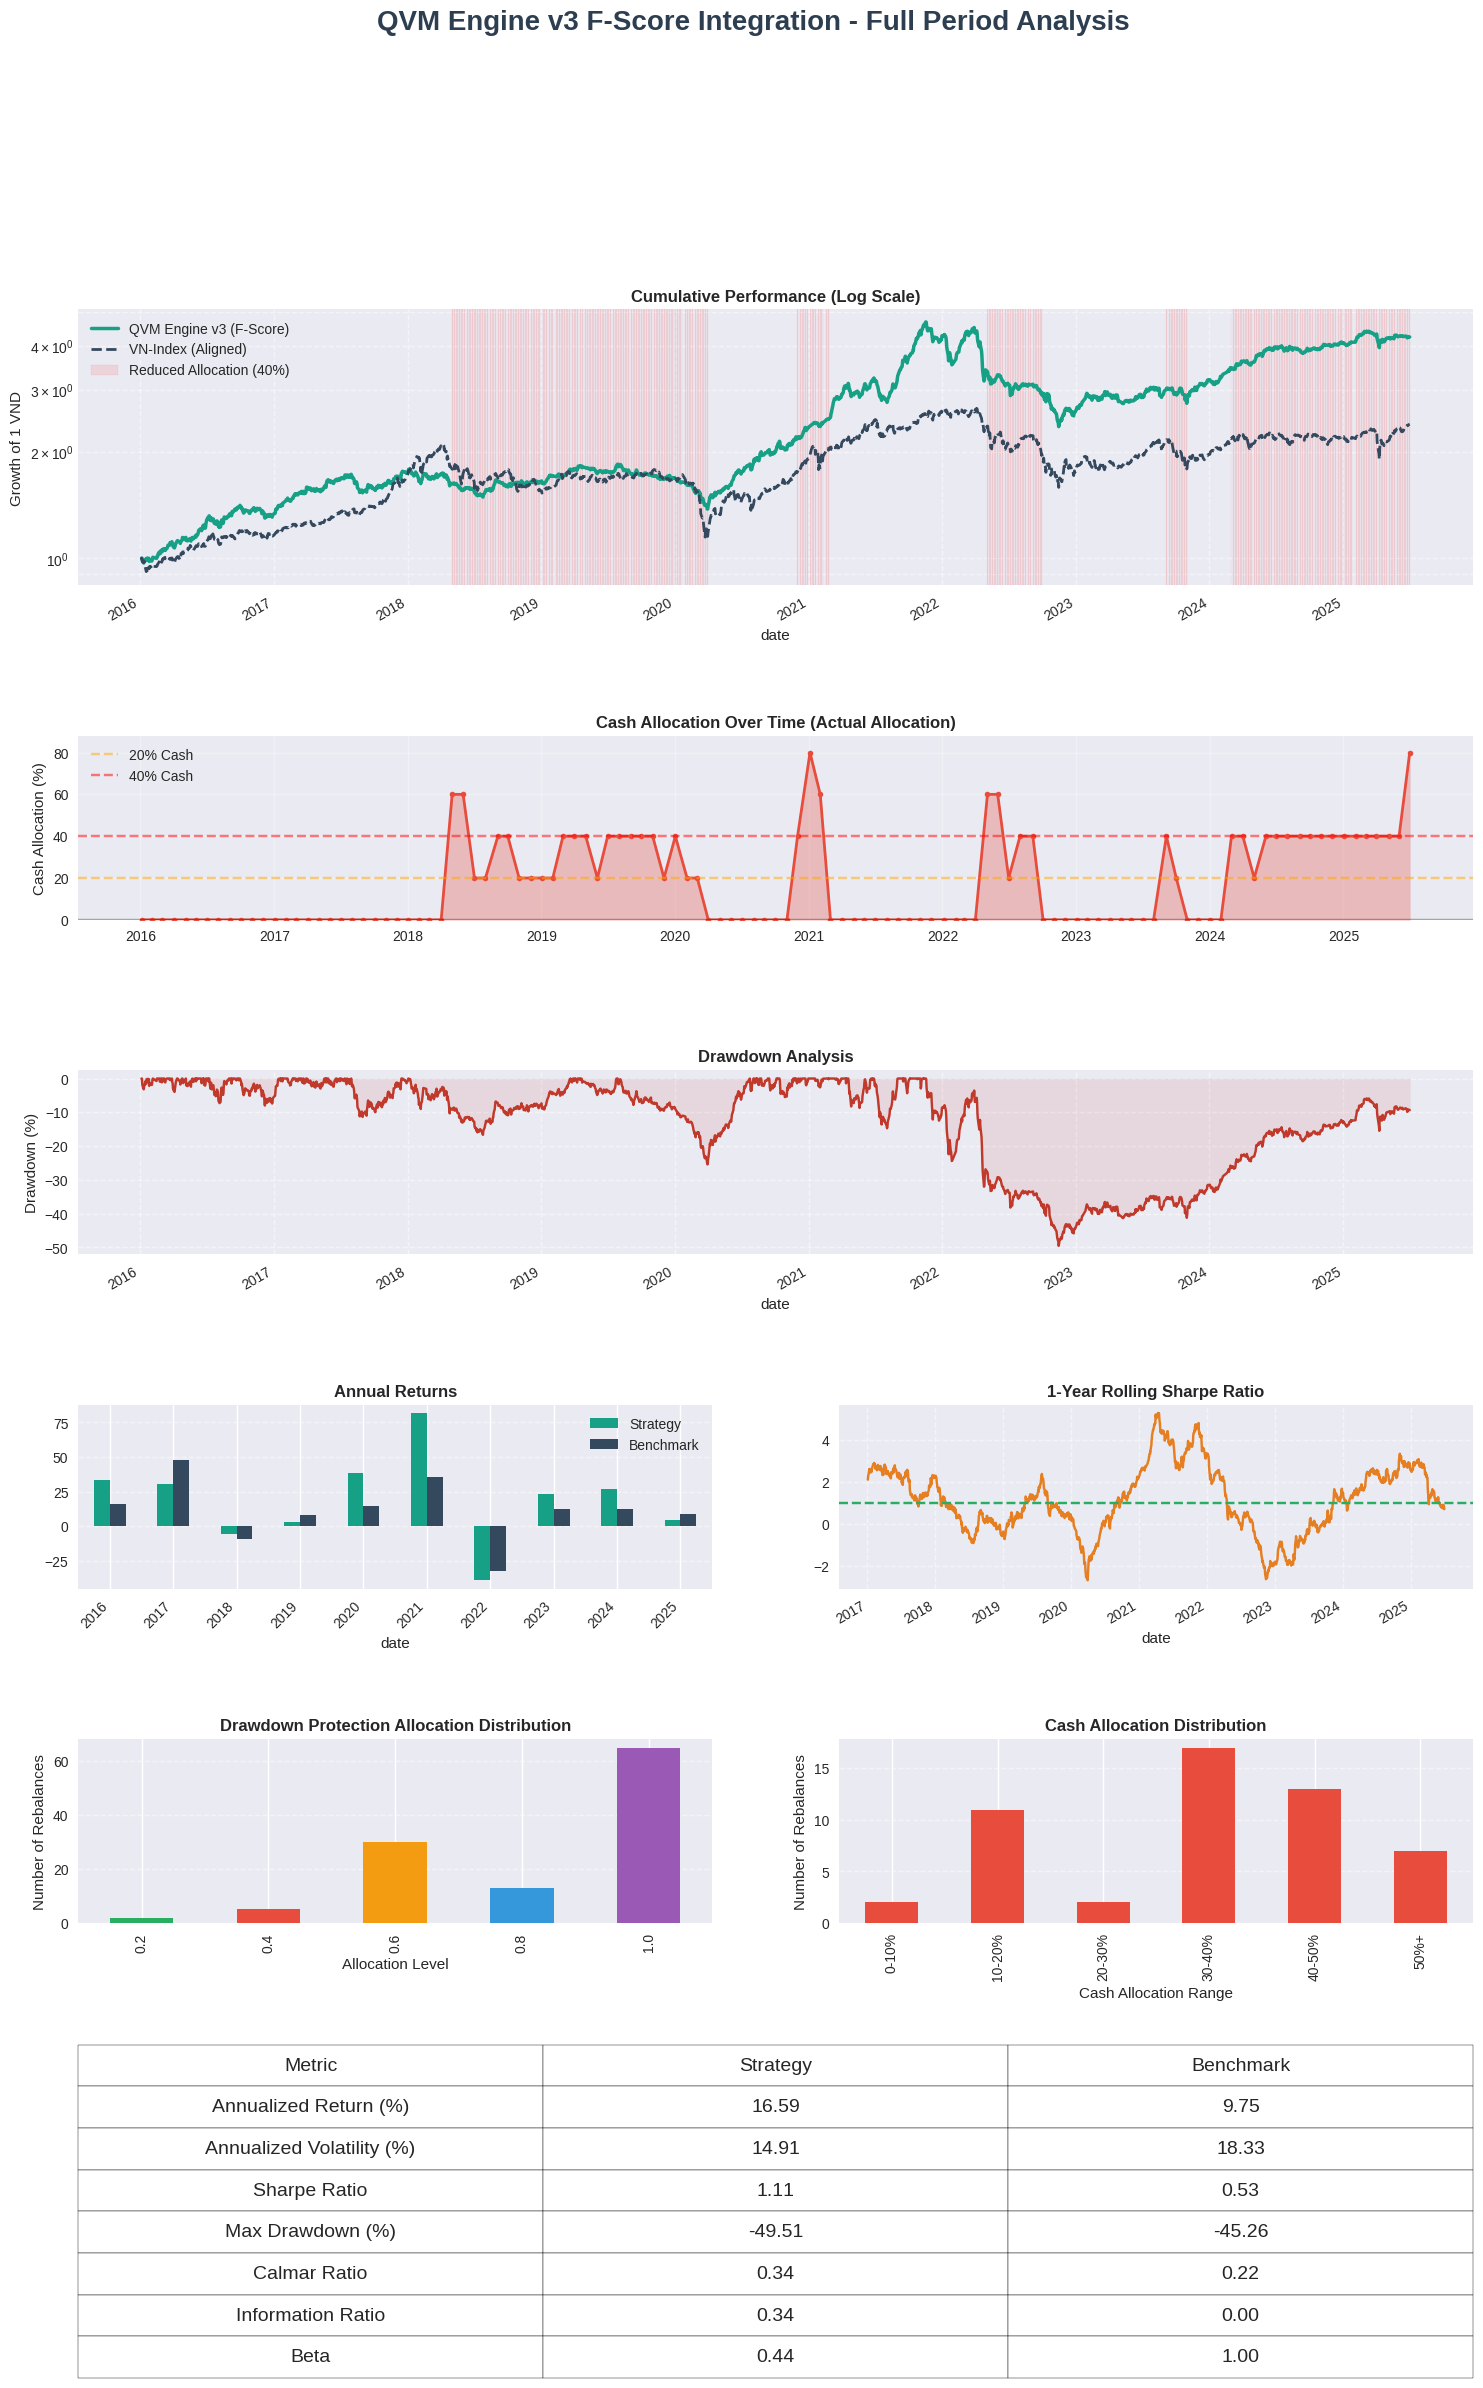

In [58]:
# Generate comprehensive tearsheet with cash allocation
print("\n" + "="*80)
print("📊 QVM ENGINE V3 F-SCORE: COMPREHENSIVE TEARSHEET")
print("="*80)

# Convert daily returns to strategy returns series
strategy_returns = daily_returns.set_index('date')['portfolio_return']
benchmark_returns = benchmark_data.set_index('date')['close_price'].pct_change()

# Create diagnostics DataFrame with F-Score integration and drawdown protection information
diagnostics = portfolio_values[['date', 'cash_allocation', 'valid_holdings', 'fscore_integration', 'allocation', 'drawdown_status']].copy()
diagnostics['portfolio_size'] = diagnostics['valid_holdings']
diagnostics = diagnostics.set_index('date')

# Generate the comprehensive tearsheet with cash allocation
generate_comprehensive_tearsheet_with_cash_allocation(
    strategy_returns,
    benchmark_returns,
    diagnostics,
    cash_allocations,
    "QVM Engine v3 F-Score Integration - Full Period Analysis"
)

# ADDITIONAL PERIOD TEARSHEETS


📊 QVM ENGINE V3 F-SCORE: FIRST PERIOD TEARSHEET (2016-2020)
   📊 Drawdown protection shading applied
   📊 Cash allocation chart created - showing actual allocation values


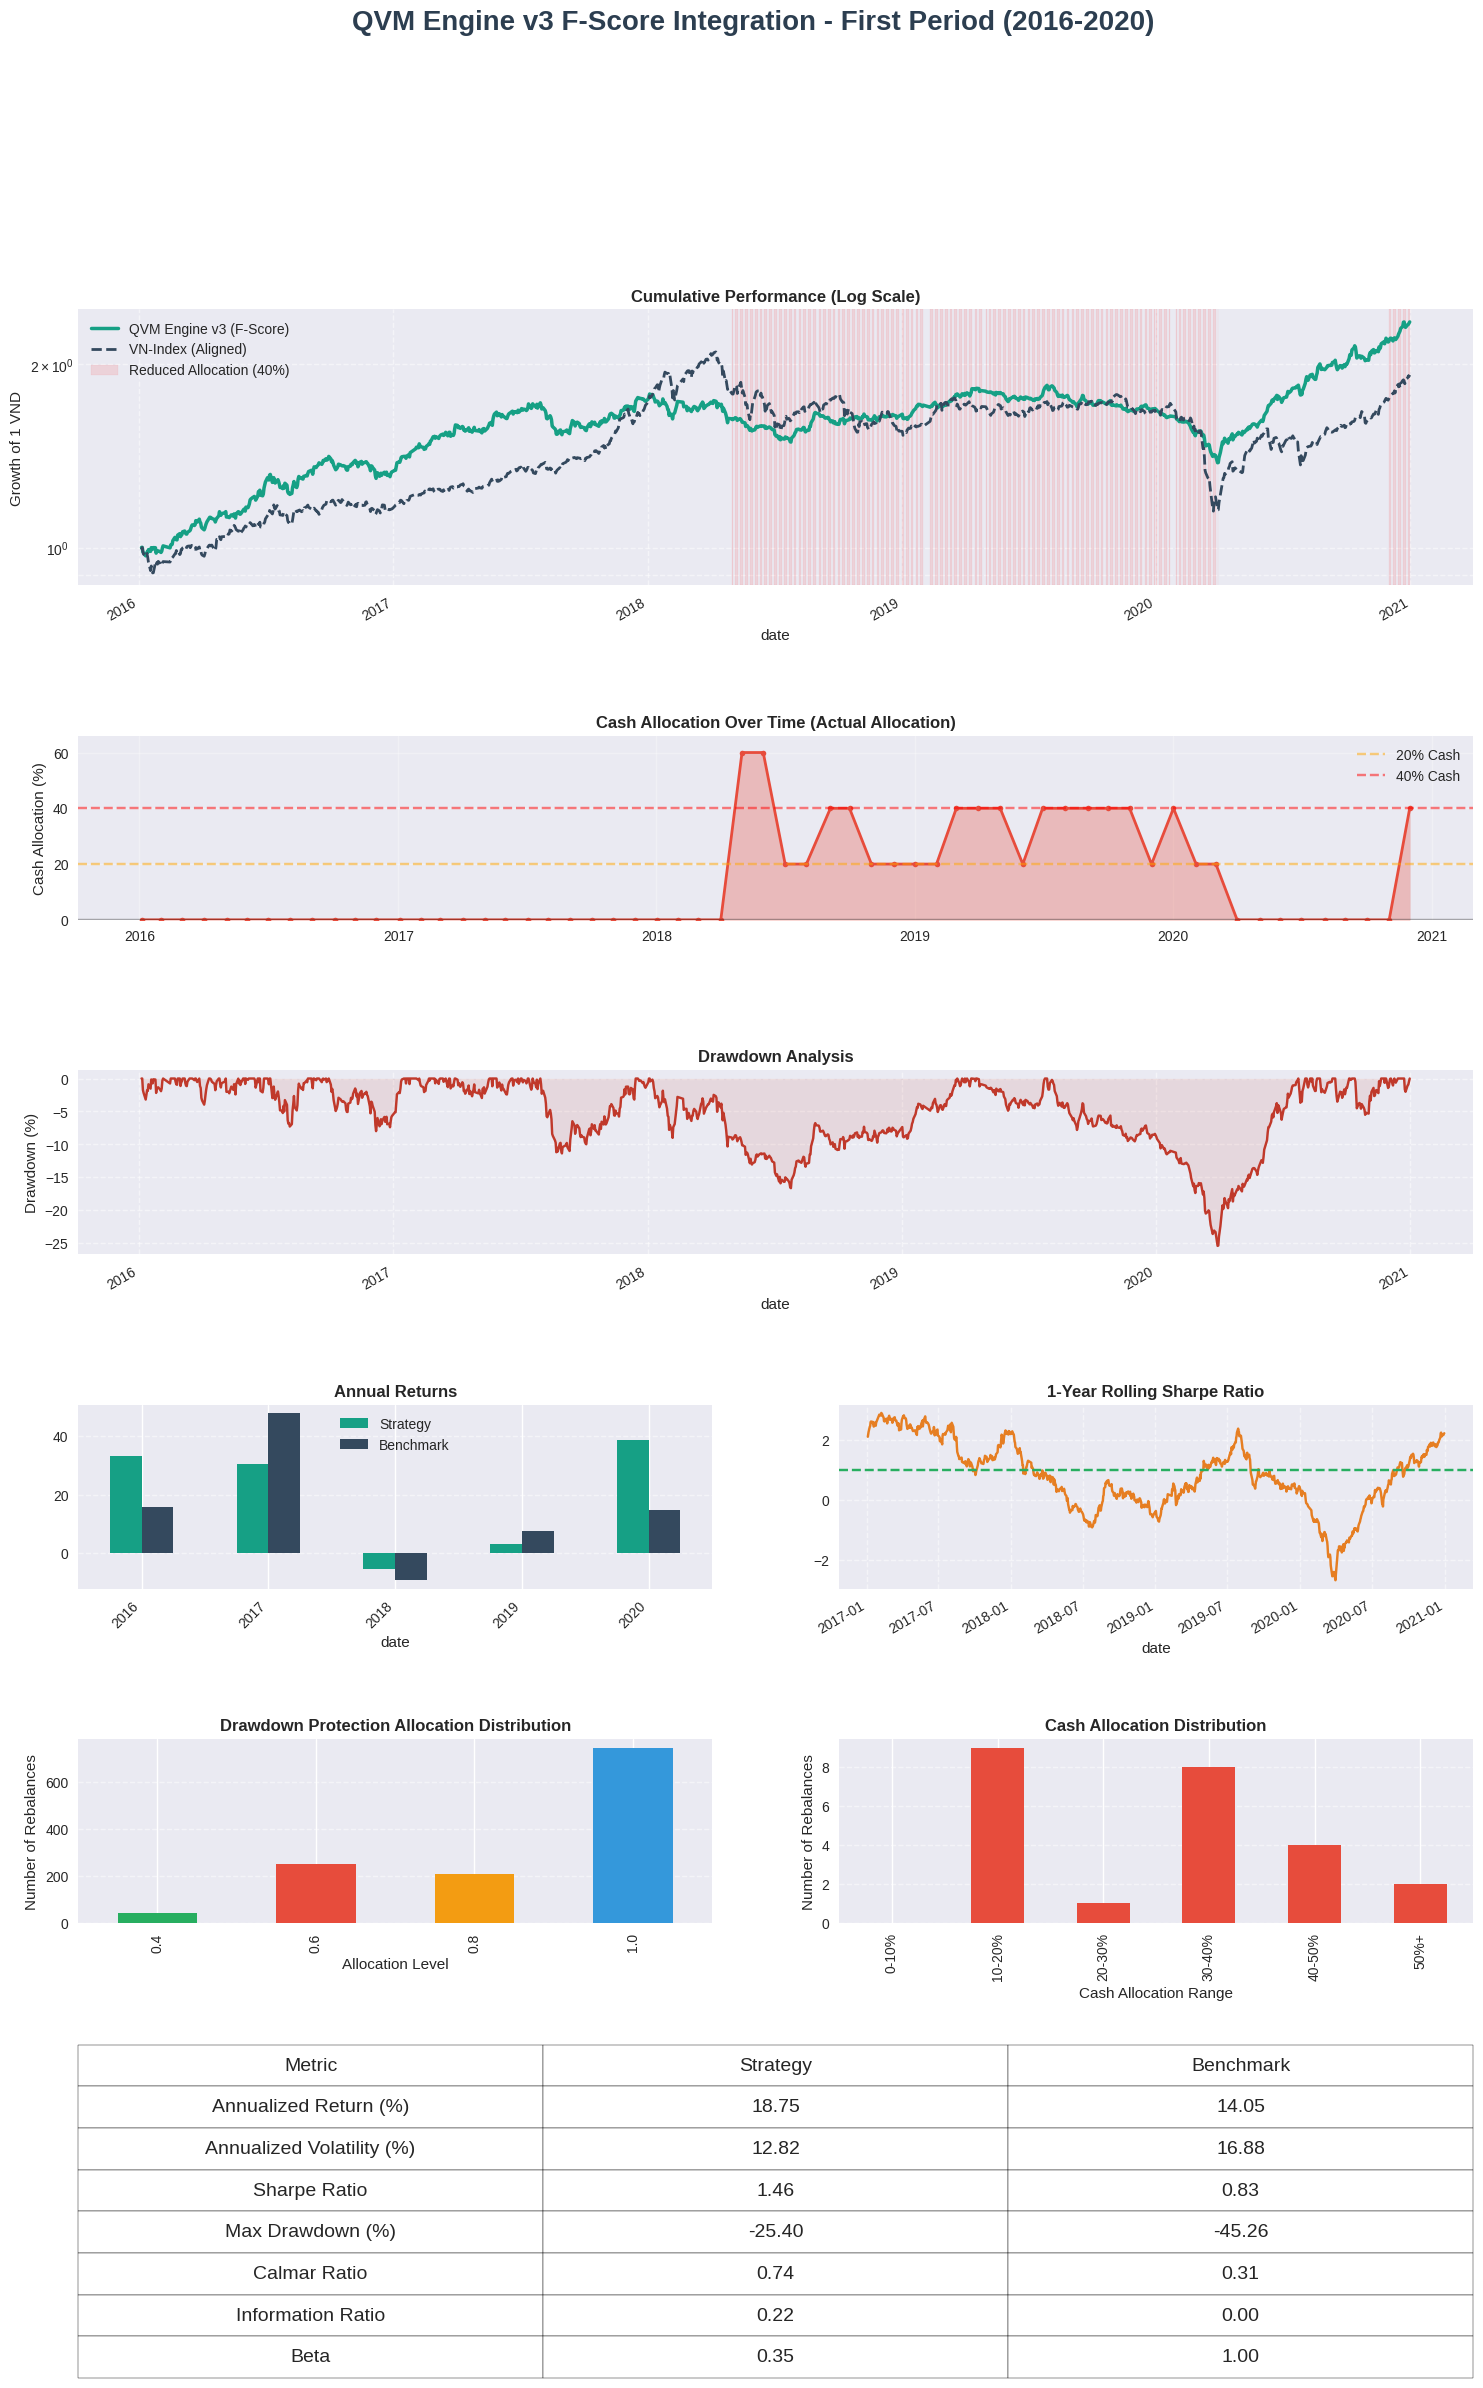


📊 QVM ENGINE V3 F-SCORE: SECOND PERIOD TEARSHEET (2020-2025)
   📊 Drawdown protection shading applied
   📊 Cash allocation chart created - showing actual allocation values


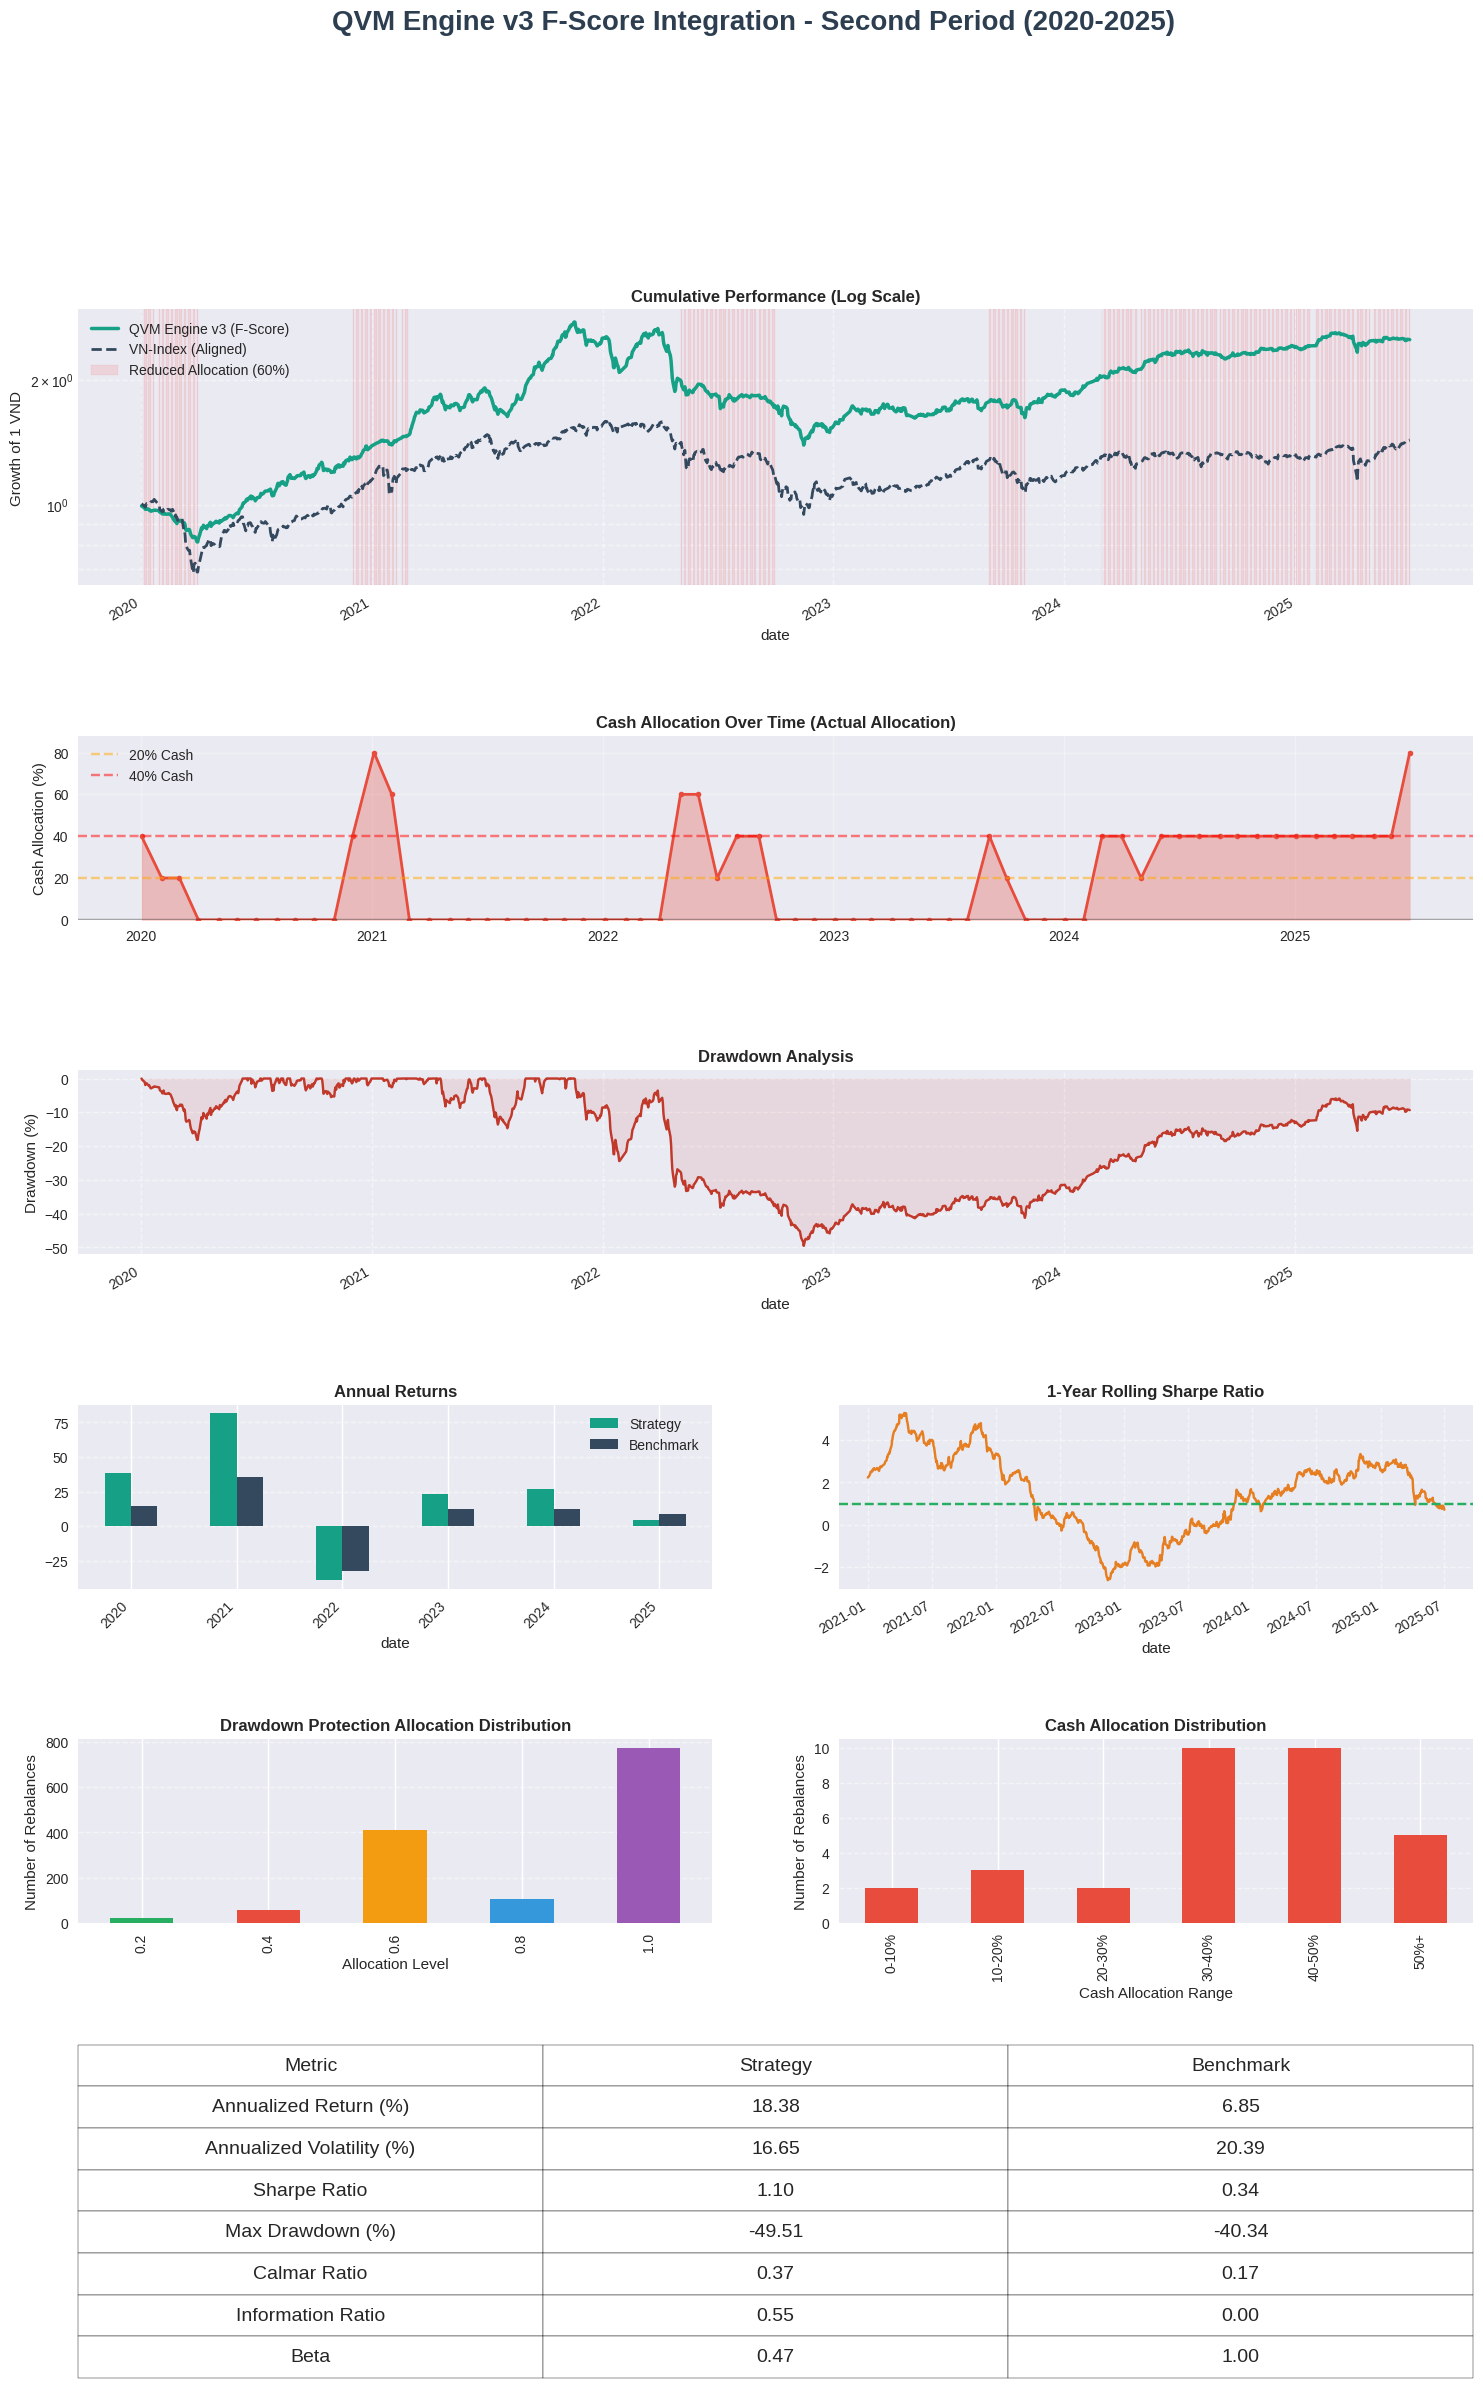

In [59]:
# 1. First Period Tearsheet (2016-2020)
print("\n" + "="*80)
print("📊 QVM ENGINE V3 F-SCORE: FIRST PERIOD TEARSHEET (2016-2020)")
print("="*80)

# Filter data for 2016-2020 period
first_period_mask = (strategy_returns.index >= '2016-01-01') & (strategy_returns.index <= '2020-12-31')
first_period_strategy_returns = strategy_returns[first_period_mask]
first_period_benchmark_returns = benchmark_returns.reindex(first_period_strategy_returns.index).fillna(0)
first_period_diagnostics = diagnostics.reindex(first_period_strategy_returns.index, method='ffill')
first_period_cash_allocations = cash_allocations[
    (cash_allocations['date'] >= '2016-01-01') & (cash_allocations['date'] <= '2020-12-31')
]

# Generate first period tearsheet
generate_comprehensive_tearsheet_with_cash_allocation(
    first_period_strategy_returns,
    first_period_benchmark_returns,
    first_period_diagnostics,
    first_period_cash_allocations,
    "QVM Engine v3 F-Score Integration - First Period (2016-2020)"
)

# 2. Second Period Tearsheet (2020-2025)
print("\n" + "="*80)
print("📊 QVM ENGINE V3 F-SCORE: SECOND PERIOD TEARSHEET (2020-2025)")
print("="*80)

# Filter data for 2020-2025 period
second_period_mask = (strategy_returns.index >= '2020-01-01') & (strategy_returns.index <= '2025-12-31')
second_period_strategy_returns = strategy_returns[second_period_mask]
second_period_benchmark_returns = benchmark_returns.reindex(second_period_strategy_returns.index).fillna(0)
second_period_diagnostics = diagnostics.reindex(second_period_strategy_returns.index, method='ffill')
second_period_cash_allocations = cash_allocations[
    (cash_allocations['date'] >= '2020-01-01') & (cash_allocations['date'] <= '2025-12-31')
]

# Generate second period tearsheet
generate_comprehensive_tearsheet_with_cash_allocation(
    second_period_strategy_returns,
    second_period_benchmark_returns,
    second_period_diagnostics,
    second_period_cash_allocations,
    "QVM Engine v3 F-Score Integration - Second Period (2020-2025)"
)

# SAVE RESULTS

In [60]:
# Dynamic filename generation
def get_output_filenames(prefix="01", suffix="fscore_integration"):
    """Generate unique filenames based on current file."""
    return {
        'portfolio_values': f"{prefix}_tearsheet_portfolio_values_{suffix}.csv",
        'daily_returns': f"{prefix}_tearsheet_daily_returns_{suffix}.csv",
        'cash_allocations': f"{prefix}_tearsheet_cash_allocations_{suffix}.csv",
        'performance_metrics': f"{prefix}_tearsheet_performance_metrics_{suffix}.txt",
        'equity_curve': f"{prefix}_equity_curve_{suffix}.png"
    }

# Save results
results_dir = Path("docs")
results_dir.mkdir(exist_ok=True)

# Get dynamic filenames
filenames = get_output_filenames("01", "fscore_integration")

portfolio_values.to_csv(results_dir / filenames['portfolio_values'], index=False)
daily_returns.to_csv(results_dir / filenames['daily_returns'], index=False)
cash_allocations.to_csv(results_dir / filenames['cash_allocations'], index=False)

# Save performance metrics
with open(results_dir / filenames['performance_metrics'], 'w') as f:
    for metric, value in performance_metrics.items():
        f.write(f"{metric}: {value}\n")

print(f"\n📁 Results saved to docs/")
print(f"   - {filenames['portfolio_values']}: {len(portfolio_values)} portfolio values")
print(f"   - {filenames['daily_returns']}: {len(daily_returns)} daily returns")
print(f"   - {filenames['cash_allocations']}: {len(cash_allocations)} cash allocations")
print(f"   - {filenames['performance_metrics']}: Performance metrics")


📁 Results saved to docs/
   - 01_tearsheet_portfolio_values_fscore_integration.csv: 115 portfolio values
   - 01_tearsheet_daily_returns_fscore_integration.csv: 2370 daily returns
   - 01_tearsheet_cash_allocations_fscore_integration.csv: 115 cash allocations
   - 01_tearsheet_performance_metrics_fscore_integration.txt: Performance metrics


# SUMMARY

In [61]:
print("\n" + "="*80)
print("🎯 QVM STRATEGY WITH F-SCORE INTEGRATION AND DRAWDOWN PROTECTION PERFORMANCE SUMMARY")
print("="*80)
print(f"📈 Total Return: {performance_metrics['total_return']:.2%}")
print(f"📊 Annualized Return: {performance_metrics['annualized_return']:.2%}")
print(f"⚡ Sharpe Ratio: {performance_metrics['sharpe_ratio']:.3f}")
print(f"📉 Max Drawdown: {performance_metrics['max_drawdown']:.2%}")
print(f"🎯 Alpha: {performance_metrics['alpha']:.2%}")
print(f"📊 Beta: {performance_metrics['beta']:.3f}")
print(f"🏆 Win Rate: {performance_metrics['win_rate']:.2%}")
print(f"💰 Average Cash Allocation: {performance_metrics['avg_cash_allocation']:.1f}%")
print(f"🔍 F-Score Effective Weight: {performance_metrics['fscore_effective_weight']:.1%}")
print(f"🛡️ Average Allocation: {performance_metrics['avg_allocation']:.1%}")
print(f"📊 Allocation Volatility: {performance_metrics['allocation_volatility']:.3f}")
print("="*80)
print("🎉 F-Score Integration and Drawdown Protection Strategy Analysis Complete!")
print("   - Piotroski F-Score integrated into Quality factor (15% weight)")
print("   - Enhanced quality factor weighting applied")
print("   - Drawdown protection with dynamic position sizing implemented")
print("   - Cash allocation tracking implemented")
print("   - Comprehensive tearsheet with drawdown protection shading generated")


🎯 QVM STRATEGY WITH F-SCORE INTEGRATION AND DRAWDOWN PROTECTION PERFORMANCE SUMMARY
📈 Total Return: 323.38%
📊 Annualized Return: 16.43%
⚡ Sharpe Ratio: 1.102
📉 Max Drawdown: -49.51%
🎯 Alpha: 12.18%
📊 Beta: 0.436
🏆 Win Rate: 55.04%
💰 Average Cash Allocation: 16.7%
🔍 F-Score Effective Weight: 5.0%
🛡️ Average Allocation: 83.3%
📊 Allocation Volatility: 0.213
🎉 F-Score Integration and Drawdown Protection Strategy Analysis Complete!
   - Piotroski F-Score integrated into Quality factor (15% weight)
   - Enhanced quality factor weighting applied
   - Drawdown protection with dynamic position sizing implemented
   - Cash allocation tracking implemented
   - Comprehensive tearsheet with drawdown protection shading generated
